# LSTM Model — Stock Return Prediction & Ranking

## Objective
Build an LSTM model to predict weekly stock return **direction** (up/down) for five major tech stocks and rank them for portfolio allocation.

**Stocks:** AAPL, MSFT, GOOGL, AMZN, NVDA

**Approach:** Binary classification (up vs down) rather than regression. In initial experiments, regression-based LSTM collapsed to flat near-zero predictions — a well-known issue in financial ML. Classification forces the model to commit to a direction and produces probability scores that can be used for ranking.

**Architecture:** Minimal single-layer LSTM with 8 units to prevent overfitting on limited weekly data (~350 training samples per stock).

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

print('All imports successful.')

All imports successful.


## 2. Configuration

In [2]:
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']
SEQUENCE_LENGTH = 4
EPOCHS = 200
BATCH_SIZE = 32
PATIENCE = 20
OUT_DIR = '../../data/results'
os.makedirs(OUT_DIR, exist_ok=True)

COLORS = {'AAPL': '#1f77b4', 'MSFT': '#ff7f0e', 'GOOGL': '#2ca02c',
          'AMZN': '#d62728', 'NVDA': '#9467bd'}

FILES = {
    'AAPL': '../../data/Apple.csv',
    'MSFT': '../../data/MSFT.csv',
    'GOOGL': '../../data/google.csv',
    'AMZN': '../../data/Amazon.csv',
    'NVDA': '../../data/NVIDIA.csv',
}

print('Configuration set.')
print(f'  Sequence length: {SEQUENCE_LENGTH} weeks')
print(f'  Max epochs: {EPOCHS}')
print(f'  Early stopping patience: {PATIENCE}')

Configuration set.
  Sequence length: 4 weeks
  Max epochs: 200
  Early stopping patience: 20


## 3. Load Raw Data

We load directly from the raw CSV files and compute weekly returns ourselves. This avoids the StandardScaler issue from the pipeline that squashed all variance out of the features.

In [3]:
frames = []
for ticker, path in FILES.items():
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df['Date'] = pd.to_datetime(df['Date'])
    for col in ['Open','High','Low','Close']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['Volume'] = pd.to_numeric(df['Volume'].astype(str).str.replace(',',''), errors='coerce')
    df = df.sort_values('Date').dropna().reset_index(drop=True)
    
    df = df.set_index('Date')
    w = pd.DataFrame()
    w['Close'] = df['Close'].resample('W-FRI').last()
    w['Weekly_Return'] = w['Close'].pct_change() * 100
    w['Return_Lag1'] = w['Weekly_Return'].shift(1)
    w['Return_Lag2'] = w['Weekly_Return'].shift(2)
    w['Ticker'] = ticker
    w = w.dropna().reset_index()
    frames.append(w)

raw = pd.concat(frames).sort_values(['Date','Ticker']).reset_index(drop=True)

train = raw[raw['Date'] <= '2021-12-31'].copy()
val   = raw[(raw['Date'] >= '2022-01-01') & (raw['Date'] <= '2023-12-31')].copy()
test  = raw[raw['Date'] >= '2024-01-01'].copy()

print(f'Total data: {len(raw)} rows')
print(f'Train: {len(train)} | Val: {len(val)} | Test: {len(test)}')
print(f'Date range: {raw["Date"].min().date()} to {raw["Date"].max().date()}')
print(f'\nClass balance (% weeks with positive return):')
for ticker in TICKERS:
    t = train[train['Ticker']==ticker]
    up_pct = (t['Weekly_Return'] > 0).mean()
    print(f'  {ticker}: {up_pct:.1%} up / {1-up_pct:.1%} down')

Total data: 2900 rows
Train: 1815 | Val: 520 | Test: 565
Date range: 2015-01-23 to 2026-02-27

Class balance (% weeks with positive return):
  AAPL: 60.1% up / 39.9% down
  MSFT: 60.6% up / 39.4% down
  GOOGL: 57.0% up / 43.0% down
  AMZN: 59.2% up / 40.8% down
  NVDA: 59.0% up / 41.0% down


## 4. Explore Weekly Returns

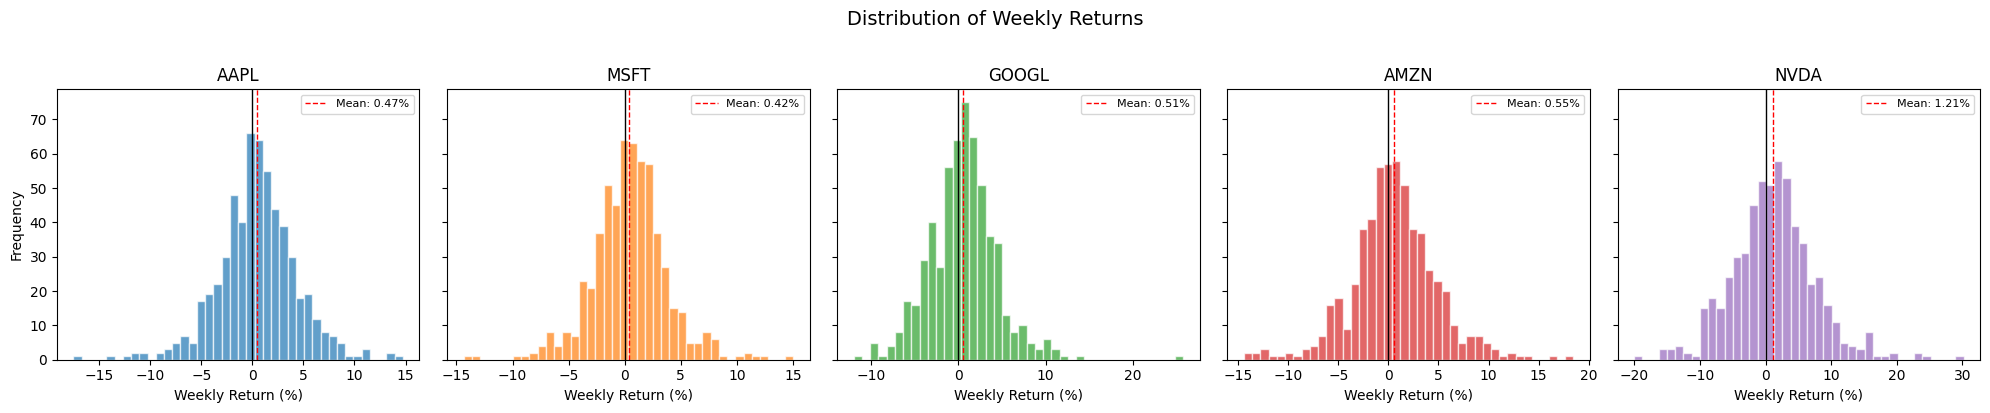

In [4]:
# Distribution of weekly returns
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for ax, ticker in zip(axes, TICKERS):
    data = raw[raw['Ticker'] == ticker]['Weekly_Return']
    ax.hist(data, bins=40, alpha=0.7, color=COLORS[ticker], edgecolor='white')
    ax.axvline(x=0, color='black', linewidth=1)
    ax.axvline(x=data.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {data.mean():.2f}%')
    ax.set_title(f'{ticker}', fontsize=12)
    ax.set_xlabel('Weekly Return (%)')
    ax.legend(fontsize=8)
    if ax == axes[0]:
        ax.set_ylabel('Frequency')

plt.suptitle('Distribution of Weekly Returns', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

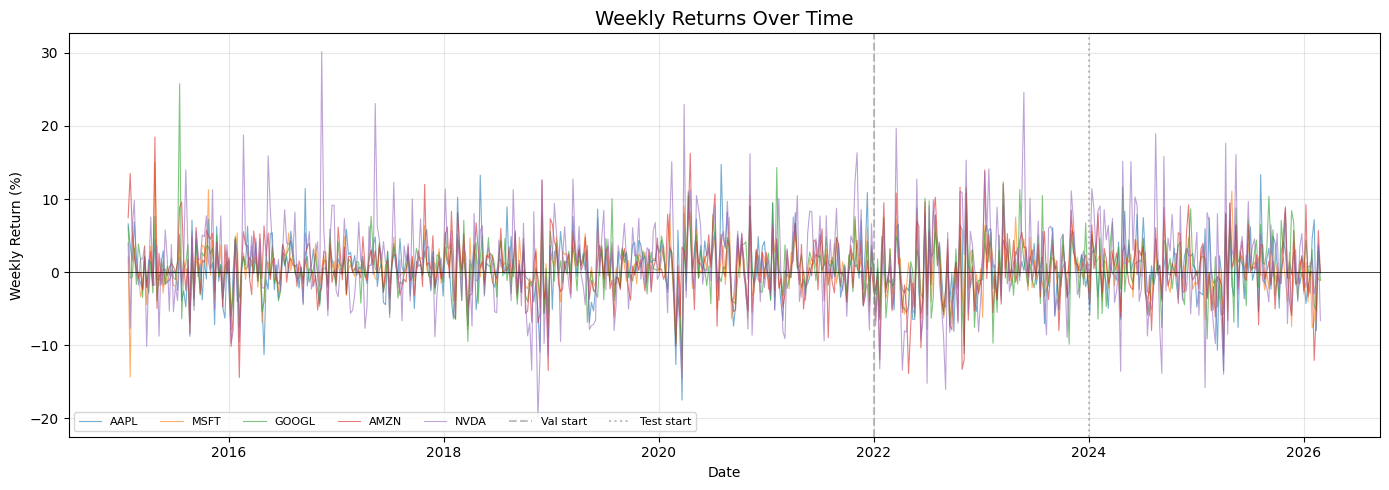

In [5]:
# Weekly returns over time
fig, ax = plt.subplots(figsize=(14, 5))
for ticker in TICKERS:
    data = raw[raw['Ticker'] == ticker].sort_values('Date')
    ax.plot(data['Date'], data['Weekly_Return'], label=ticker,
            alpha=0.6, linewidth=0.8, color=COLORS[ticker])

ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=pd.Timestamp('2022-01-01'), color='gray', linestyle='--', alpha=0.5, label='Val start')
ax.axvline(x=pd.Timestamp('2024-01-01'), color='gray', linestyle=':', alpha=0.5, label='Test start')
ax.set_title('Weekly Returns Over Time', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Weekly Return (%)')
ax.legend(loc='lower left', ncol=7, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Volatility stats
vol_stats = []
for ticker in TICKERS:
    data = raw[raw['Ticker'] == ticker]['Weekly_Return']
    vol_stats.append({
        'Ticker': ticker,
        'Mean (%)': round(data.mean(), 2),
        'Std Dev (%)': round(data.std(), 2),
        'Min (%)': round(data.min(), 2),
        'Max (%)': round(data.max(), 2),
        'Up Weeks (%)': round((data > 0).mean() * 100, 1)
    })
vol_df = pd.DataFrame(vol_stats).set_index('Ticker')
print('Weekly Return Statistics:')
vol_df

Weekly Return Statistics:


,Mean (%),Std Dev (%),Min (%),Max (%),Up Weeks (%)
Ticker,,,,,
AAPL,0.47,3.83,-17.53,14.74,57.1
MSFT,0.42,3.31,-14.37,15.02,57.1
GOOGL,0.51,3.89,-12.02,25.78,56.6
AMZN,0.55,4.24,-14.45,18.48,56.6
NVDA,1.21,6.29,-20.04,30.18,58.1


## 5. Sequence Creation & Model Architecture

**Input:** Past 4 weeks of raw weekly returns (no scaling needed — returns are already in % and comparable across stocks).

**Target:** Binary — did the stock go up (1) or down (0) this week?

**Architecture:** LSTM(8) → Dense(1, sigmoid). Deliberately minimal to prevent overfitting on ~350 training samples.

In [7]:
def make_sequences(df, seq_len=SEQUENCE_LENGTH):
    """Create sequences from weekly return data."""
    ret = df['Weekly_Return'].values
    dates = df['Date'].values
    X, y, d = [], [], []
    for i in range(seq_len, len(df)):
        X.append(ret[i-seq_len:i].reshape(-1, 1))
        y.append(1.0 if ret[i] > 0 else 0.0)
        d.append(dates[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(d)

def build_model():
    """Minimal LSTM classifier."""
    model = Sequential([
        LSTM(8, input_shape=(SEQUENCE_LENGTH, 1)),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Show model
sample = build_model()
sample.summary()
print(f'\nTotal parameters: {sample.count_params()}')
print(f'Input: {SEQUENCE_LENGTH} weeks x 1 feature (weekly return)')
print(f'Output: probability of stock going UP')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8)              │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329 (1.29 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 329
Input: 4 weeks x 1 feature (weekly return)
Output: probability of stock going UP


## 6. Train LSTM for All 5 Stocks

A separate model per stock. Each sees 4 weeks of past returns and predicts up/down for the next week.

**This cell takes 1-2 minutes.**

In [8]:
all_predictions = []
all_histories = {}
all_metrics = {}

for ticker in TICKERS:
    print(f'\n{"="*55}')
    print(f'  Training LSTM for {ticker}')
    print(f'{"="*55}')
    
    tr = train[train['Ticker']==ticker].sort_values('Date').reset_index(drop=True)
    va = val[val['Ticker']==ticker].sort_values('Date').reset_index(drop=True)
    te = test[test['Ticker']==ticker].sort_values('Date').reset_index(drop=True)
    
    X_tr, y_tr, d_tr = make_sequences(tr)
    X_va, y_va, d_va = make_sequences(va)
    X_te, y_te, d_te = make_sequences(te)
    
    print(f'  Train: {len(X_tr)} | Val: {len(X_va)} | Test: {len(X_te)}')
    print(f'  Class balance: {y_tr.mean():.1%} up | test: {y_te.mean():.1%} up')
    
    model = build_model()
    
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[EarlyStopping(monitor='val_loss', patience=PATIENCE,
                                 restore_best_weights=True, verbose=0)],
        verbose=0
    )
    
    stopped = len(history.history['loss'])
    all_histories[ticker] = history
    
    probs = model.predict(X_te, verbose=0).flatten()
    preds = (probs > 0.5).astype(int)
    acc = np.mean(preds == y_te)
    
    print(f'  Epochs: {stopped} | Accuracy: {acc:.2%}')
    print(f'  Prob range: [{probs.min():.3f} - {probs.max():.3f}], std: {probs.std():.3f}')
    print(f'  Preds: {preds.sum():.0f} up / {len(preds)-preds.sum():.0f} down')
    
    all_metrics[ticker] = {
        'Directional Accuracy': round(acc, 4),
        'Prob Std': round(probs.std(), 4),
        'Preds Up': int(preds.sum()),
        'Preds Down': int(len(preds) - preds.sum()),
        'Stopped Epoch': stopped,
        'Test Samples': len(y_te)
    }
    
    raw_ret = te['Weekly_Return'].values[SEQUENCE_LENGTH:]
    for i in range(len(probs)):
        all_predictions.append({
            'Date': pd.Timestamp(d_te[i]),
            'Ticker': ticker,
            'Predicted_Return': float(probs[i]),
            'Actual_Return': float(raw_ret[i]),
            'Pred_Direction': int(preds[i]),
            'Actual_Direction': int(y_te[i])
        })

print('\n' + '='*55)
print('  RESULTS SUMMARY')
print('='*55)
for t, m in all_metrics.items():
    print(f'  {t}: {m["Directional Accuracy"]:.1%}  |  std: {m["Prob Std"]:.3f}  |  {m["Preds Up"]} up / {m["Preds Down"]} down')


  Training LSTM for AAPL
  Train: 359 | Val: 100 | Test: 109
  Class balance: 59.6% up | test: 53.2% up
  Epochs: 21 | Accuracy: 52.29%
  Prob range: [0.494 - 0.686], std: 0.039
  Preds: 106 up / 3 down

  Training LSTM for MSFT
  Train: 359 | Val: 100 | Test: 109
  Class balance: 60.4% up | test: 53.2% up
  Epochs: 21 | Accuracy: 53.21%
  Prob range: [0.521 - 0.596], std: 0.012
  Preds: 109 up / 0 down

  Training LSTM for GOOGL
  Train: 359 | Val: 100 | Test: 109
  Class balance: 57.1% up | test: 60.6% up
  Epochs: 31 | Accuracy: 55.96%
  Prob range: [0.397 - 0.682], std: 0.079
  Preds: 76 up / 33 down

  Training LSTM for AMZN
  Train: 359 | Val: 100 | Test: 109
  Class balance: 58.8% up | test: 52.3% up
  Epochs: 21 | Accuracy: 52.29%
  Prob range: [0.527 - 0.640], std: 0.024
  Preds: 109 up / 0 down

  Training LSTM for NVDA
  Train: 359 | Val: 100 | Test: 109
  Class balance: 58.8% up | test: 61.5% up
  Epochs: 28 | Accuracy: 58.72%
  Prob range: [0.343 - 0.867], std: 0.109
  Pr

## 7. Training Accuracy Curves

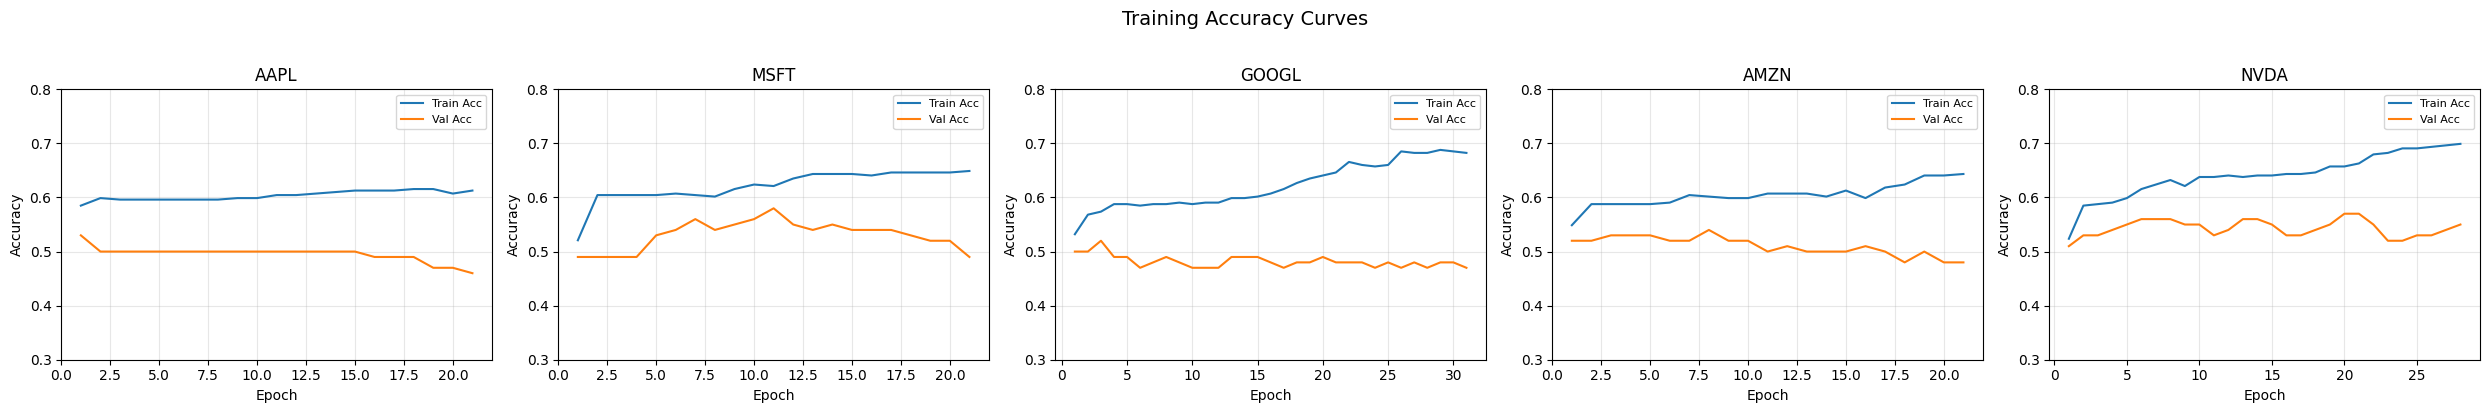

Saved: ../../data/results/lstm_training_accuracy.png


In [9]:
fig, axes = plt.subplots(1, len(all_histories), figsize=(5 * len(all_histories), 4))
if len(all_histories) == 1:
    axes = [axes]

for ax, (ticker, hist) in zip(axes, all_histories.items()):
    epochs_range = range(1, len(hist.history['accuracy']) + 1)
    ax.plot(epochs_range, hist.history['accuracy'], label='Train Acc', color='#1f77b4', linewidth=1.5)
    ax.plot(epochs_range, hist.history['val_accuracy'], label='Val Acc', color='#ff7f0e', linewidth=1.5)
    ax.set_title(f'{ticker}', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.3, 0.8)

plt.suptitle('Training Accuracy Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/lstm_training_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/lstm_training_accuracy.png')

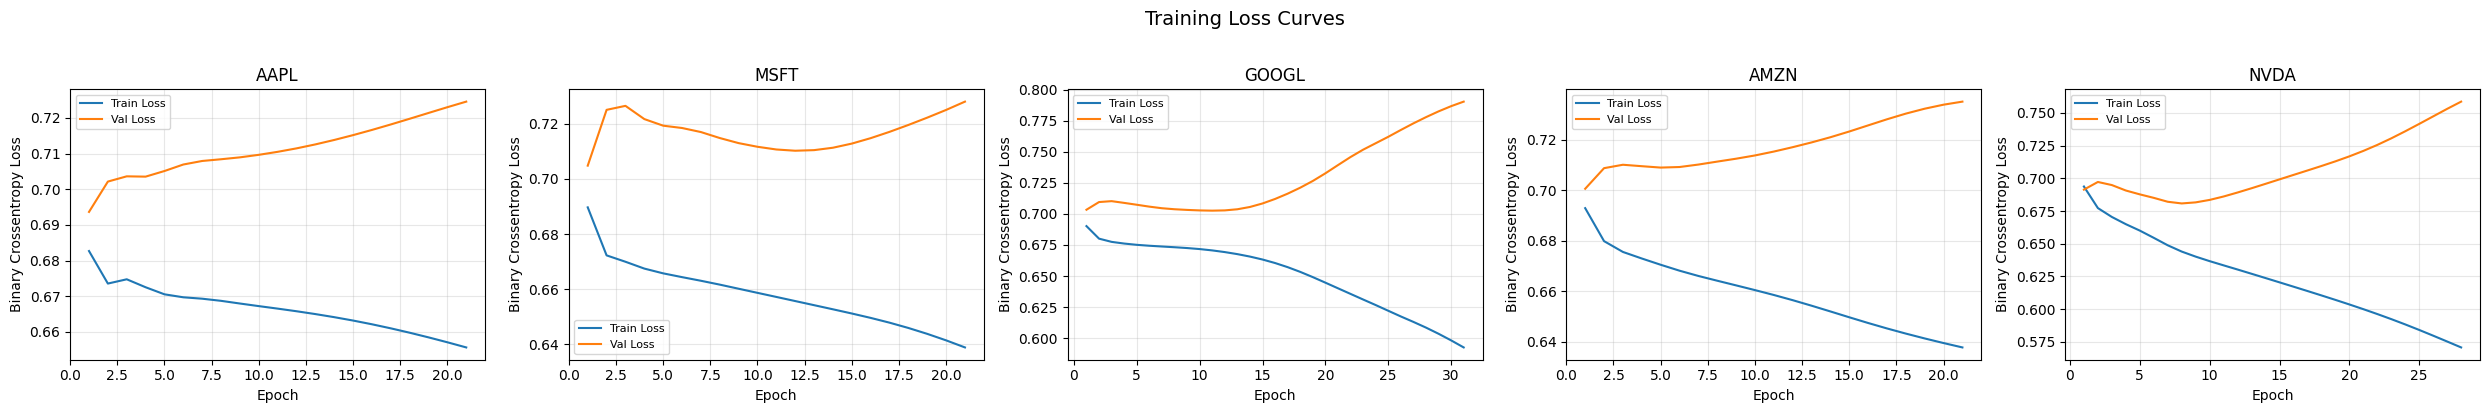

Saved: ../../data/results/lstm_training_loss.png


In [10]:
# Also plot loss curves
fig, axes = plt.subplots(1, len(all_histories), figsize=(5 * len(all_histories), 4))
if len(all_histories) == 1:
    axes = [axes]

for ax, (ticker, hist) in zip(axes, all_histories.items()):
    epochs_range = range(1, len(hist.history['loss']) + 1)
    ax.plot(epochs_range, hist.history['loss'], label='Train Loss', color='#1f77b4', linewidth=1.5)
    ax.plot(epochs_range, hist.history['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=1.5)
    ax.set_title(f'{ticker}', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Binary Crossentropy Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Loss Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/lstm_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/lstm_training_loss.png')

## 8. Save Predictions

In [11]:
pred_df = pd.DataFrame(all_predictions)
pred_df = pred_df.sort_values(['Date', 'Ticker']).reset_index(drop=True)

pred_df[['Date', 'Ticker', 'Predicted_Return']].to_csv(
    f'{OUT_DIR}/lstm_predictions.csv', index=False
)

print(f'Saved: {OUT_DIR}/lstm_predictions.csv')
print(f'Shape: {pred_df.shape}')
pred_df.head(10)

Saved: ../../data/results/lstm_predictions.csv
Shape: (545, 6)


,Date,Ticker,Predicted_Return,Actual_Return,Pred_Direction,Actual_Direction
0,2024-02-02,AAPL,0.576530,-3.414406,1,0
1,2024-02-02,AMZN,0.613084,7.975113,1,1
2,2024-02-02,GOOGL,0.421679,-6.445890,0,0
3,2024-02-02,MSFT,0.577997,1.804768,1,1
4,2024-02-02,NVDA,0.550473,8.405702,1,1
5,2024-02-09,AAPL,0.571037,1.614205,1,1
6,2024-02-09,AMZN,0.580976,1.536581,1,1
7,2024-02-09,GOOGL,0.546803,4.649529,1,1
8,2024-02-09,MSFT,0.584883,2.268859,1,1
9,2024-02-09,NVDA,0.542681,9.023579,1,1


## 9. Predicted Probability Over Time

Unlike regression where the model collapsed to a flat line near zero, classification produces probability scores that vary over time. Higher probability = model is more confident the stock will go up.

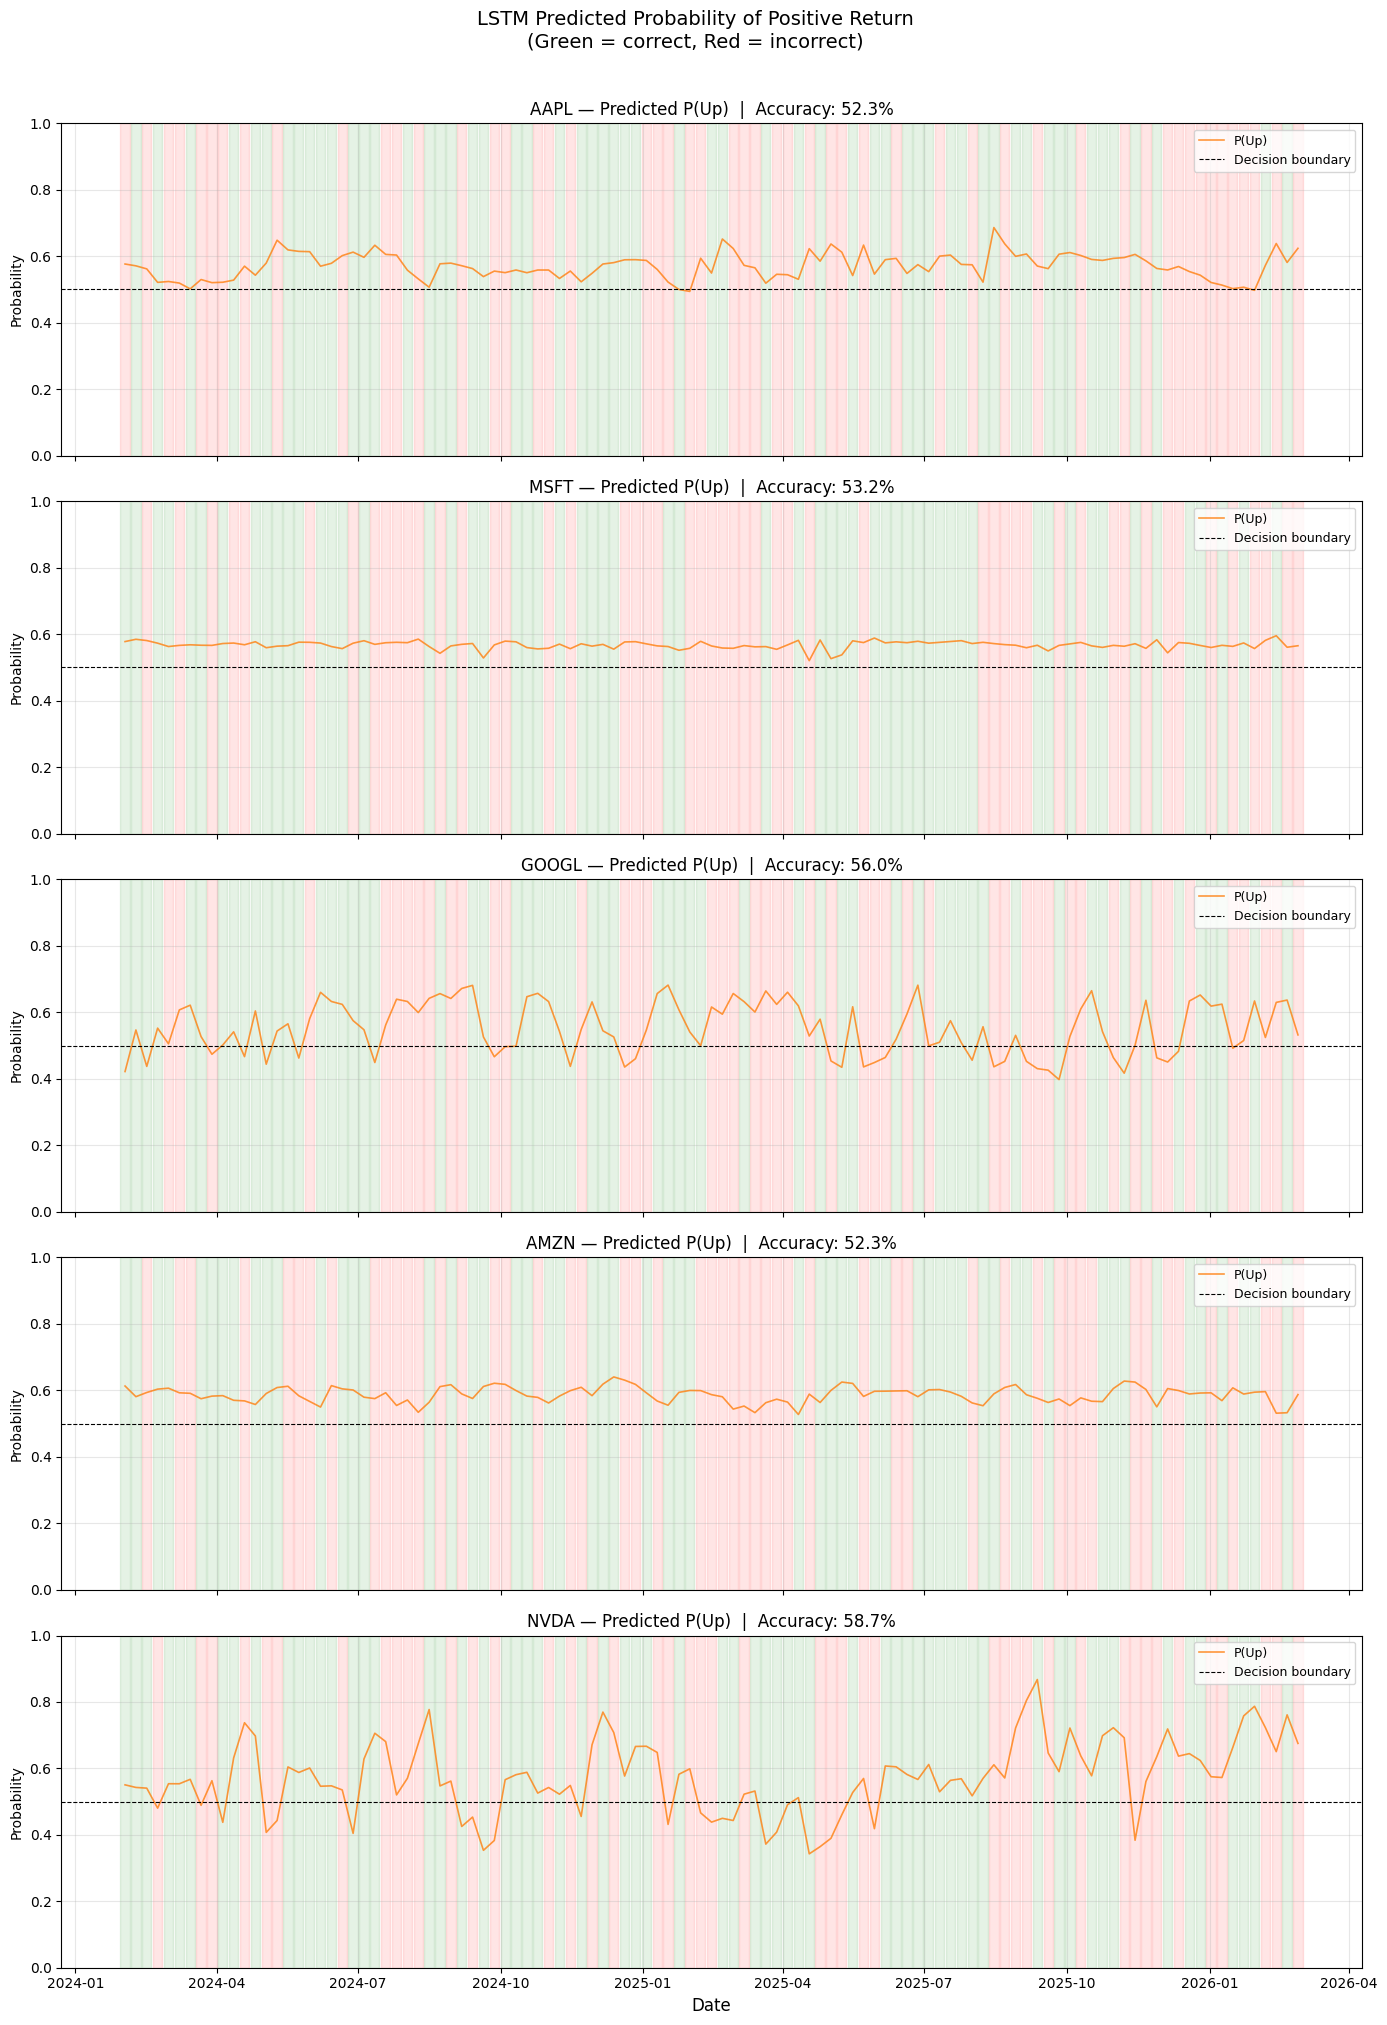

Saved: ../../data/results/lstm_probability_over_time.png


In [12]:
fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=True)

for ax, ticker in zip(axes, TICKERS):
    td = pred_df[pred_df['Ticker'] == ticker].sort_values('Date')
    if len(td) == 0:
        continue
    
    # Plot probability
    ax.plot(td['Date'], td['Predicted_Return'], label='P(Up)',
            alpha=0.8, linewidth=1.2, color='#ff7f0e')
    ax.axhline(y=0.5, color='black', linewidth=0.8, linestyle='--', label='Decision boundary')
    
    # Shade correct/incorrect
    for i in range(len(td)):
        correct = td['Pred_Direction'].iloc[i] == td['Actual_Direction'].iloc[i]
        color = 'green' if correct else 'red'
        ax.axvspan(td['Date'].iloc[i] - pd.Timedelta(days=3),
                   td['Date'].iloc[i] + pd.Timedelta(days=3),
                   alpha=0.1, color=color)
    
    dir_acc = all_metrics.get(ticker, {}).get('Directional Accuracy', 0)
    ax.set_title(f'{ticker} — Predicted P(Up)  |  Accuracy: {dir_acc:.1%}', fontsize=12)
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.xlabel('Date', fontsize=12)
plt.suptitle('LSTM Predicted Probability of Positive Return\n(Green = correct, Red = incorrect)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/lstm_probability_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/lstm_probability_over_time.png')

## 10. Actual Returns with Buy/Sell Signals

Shows when the model said UP (buy) vs DOWN (avoid) overlaid on the actual return.

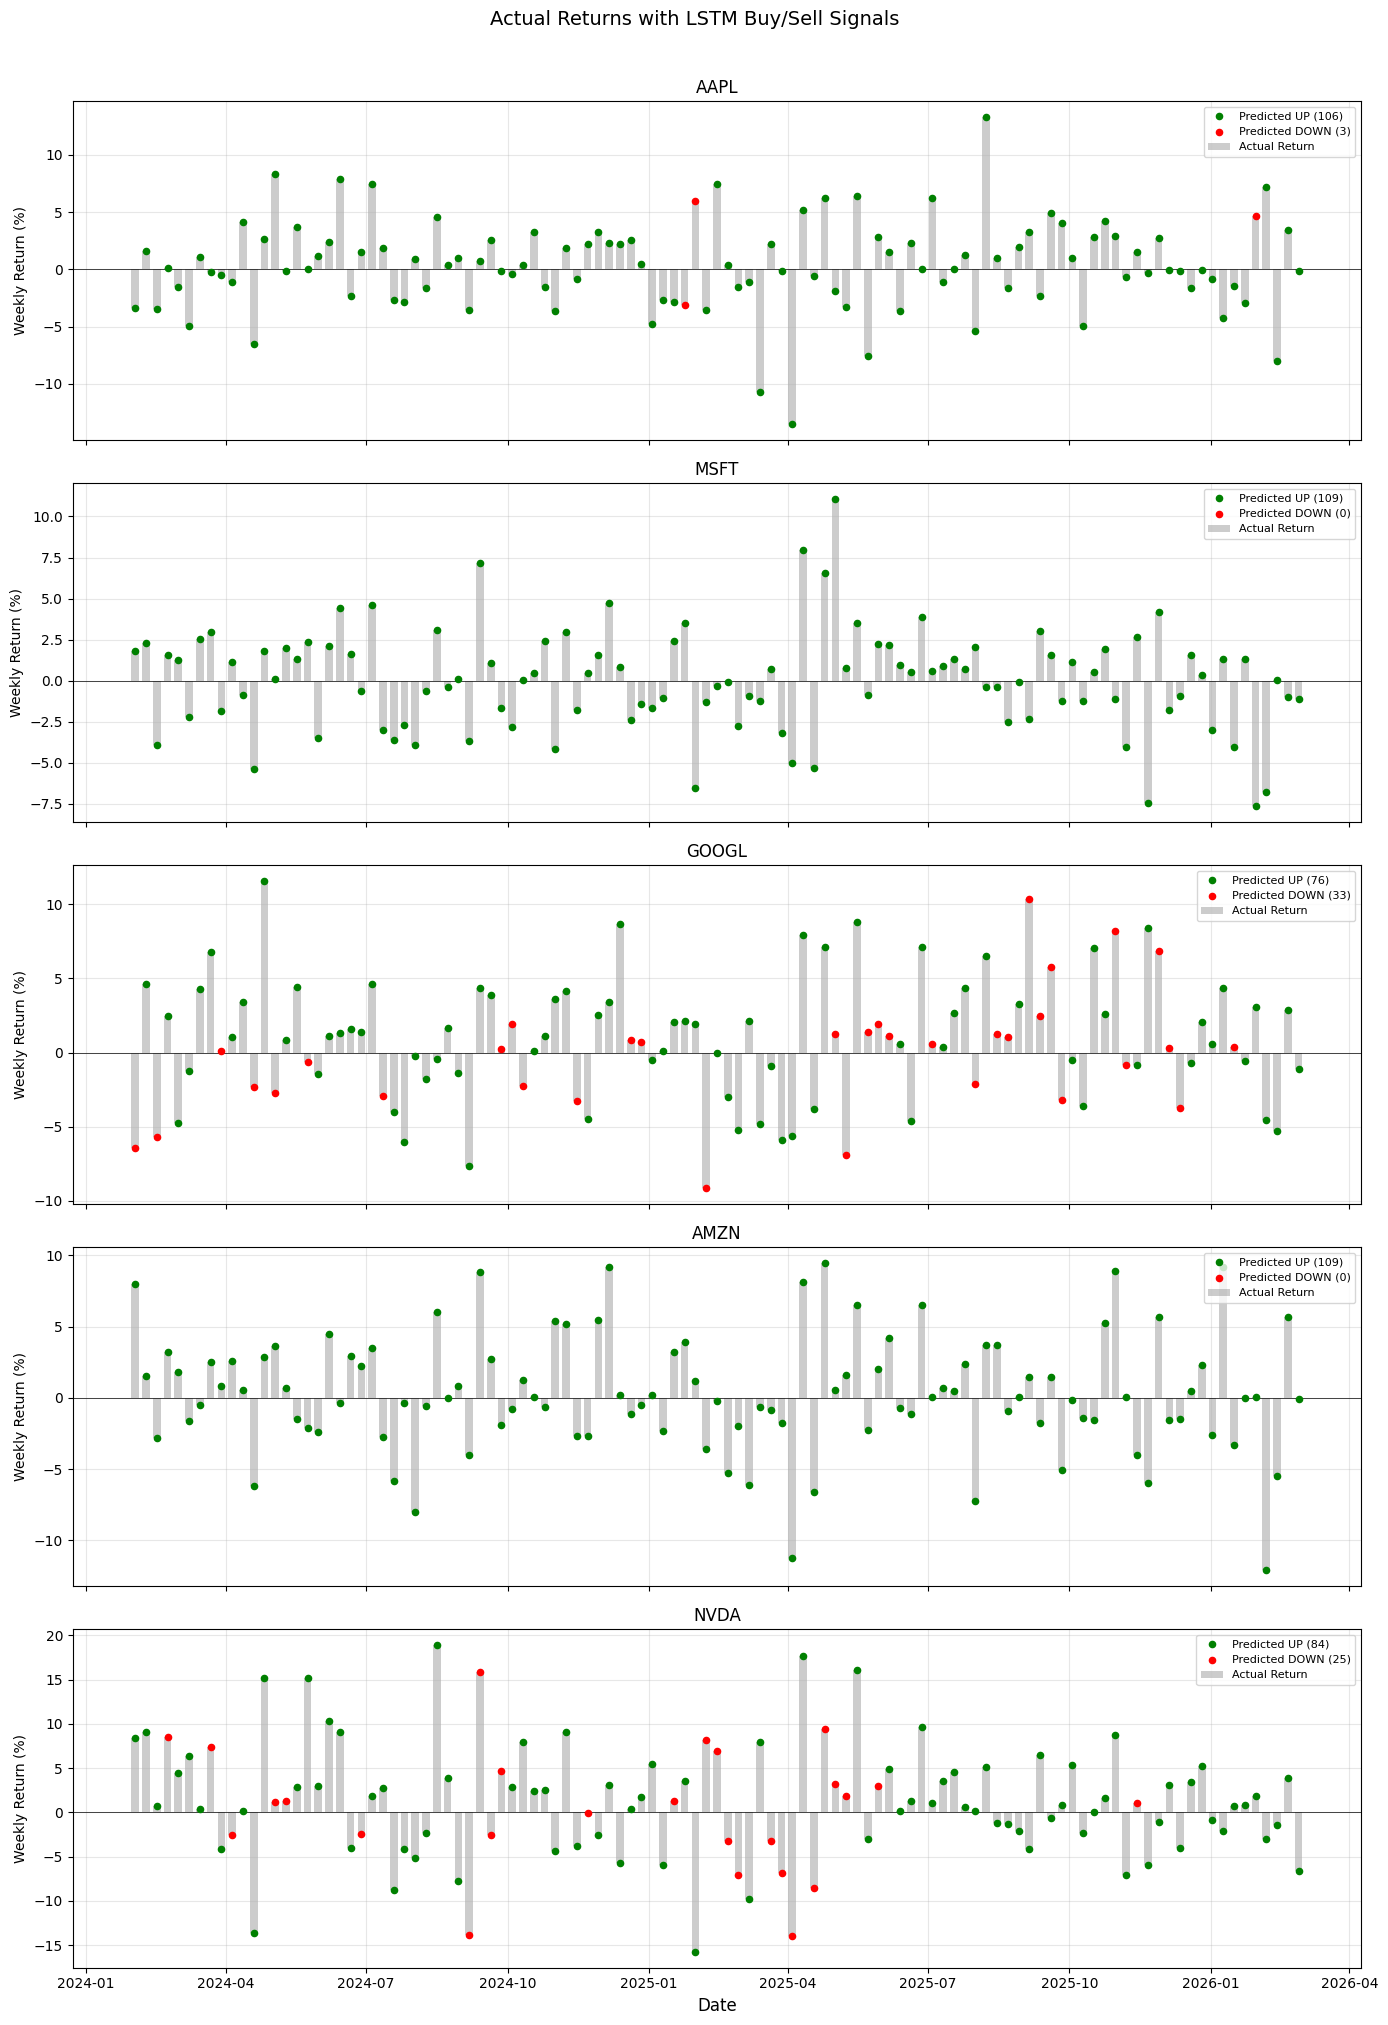

Saved: ../../data/results/lstm_signals.png


In [13]:
fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=True)

for ax, ticker in zip(axes, TICKERS):
    td = pred_df[pred_df['Ticker'] == ticker].sort_values('Date')
    if len(td) == 0:
        continue
    
    ax.bar(td['Date'], td['Actual_Return'], alpha=0.4, width=5, color='gray', label='Actual Return')
    
    buy = td[td['Pred_Direction'] == 1]
    sell = td[td['Pred_Direction'] == 0]
    ax.scatter(buy['Date'], buy['Actual_Return'], color='green', s=20, label=f'Predicted UP ({len(buy)})', zorder=5)
    ax.scatter(sell['Date'], sell['Actual_Return'], color='red', s=20, label=f'Predicted DOWN ({len(sell)})', zorder=5)
    
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_title(f'{ticker}', fontsize=12)
    ax.set_ylabel('Weekly Return (%)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.xlabel('Date', fontsize=12)
plt.suptitle('Actual Returns with LSTM Buy/Sell Signals', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/lstm_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/lstm_signals.png')

## 11. Prediction Distribution

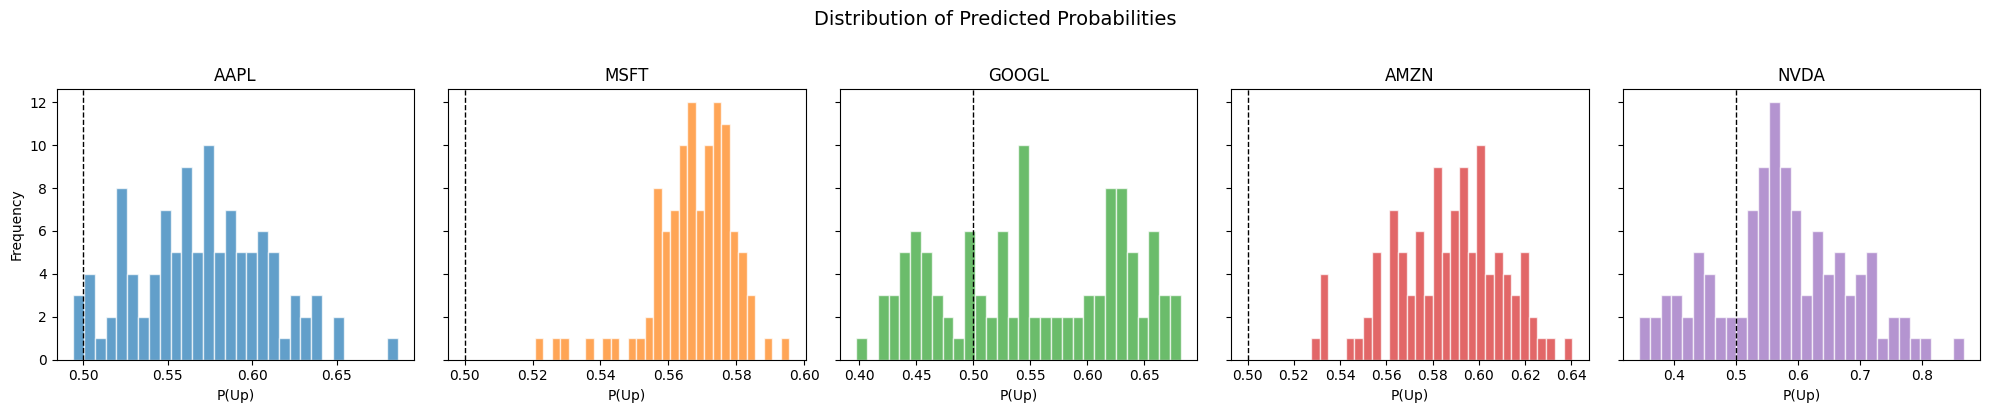

Prediction stats:
  AAPL: mean=0.570  std=0.039  range=[0.494, 0.686]
  MSFT: mean=0.568  std=0.012  range=[0.521, 0.596]
  GOOGL: mean=0.551  std=0.079  range=[0.397, 0.682]
  AMZN: mean=0.587  std=0.024  range=[0.527, 0.640]
  NVDA: mean=0.574  std=0.110  range=[0.343, 0.867]


In [14]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for ax, ticker in zip(axes, TICKERS):
    td = pred_df[pred_df['Ticker'] == ticker]
    ax.hist(td['Predicted_Return'], bins=30, alpha=0.7, color=COLORS[ticker], edgecolor='white')
    ax.axvline(x=0.5, color='black', linewidth=1, linestyle='--')
    ax.set_title(f'{ticker}', fontsize=12)
    ax.set_xlabel('P(Up)')
    if ax == axes[0]:
        ax.set_ylabel('Frequency')

plt.suptitle('Distribution of Predicted Probabilities', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Prediction stats:')
for ticker in TICKERS:
    td = pred_df[pred_df['Ticker'] == ticker]
    print(f'  {ticker}: mean={td["Predicted_Return"].mean():.3f}  '
          f'std={td["Predicted_Return"].std():.3f}  '
          f'range=[{td["Predicted_Return"].min():.3f}, {td["Predicted_Return"].max():.3f}]')

## 12. Confusion Matrices

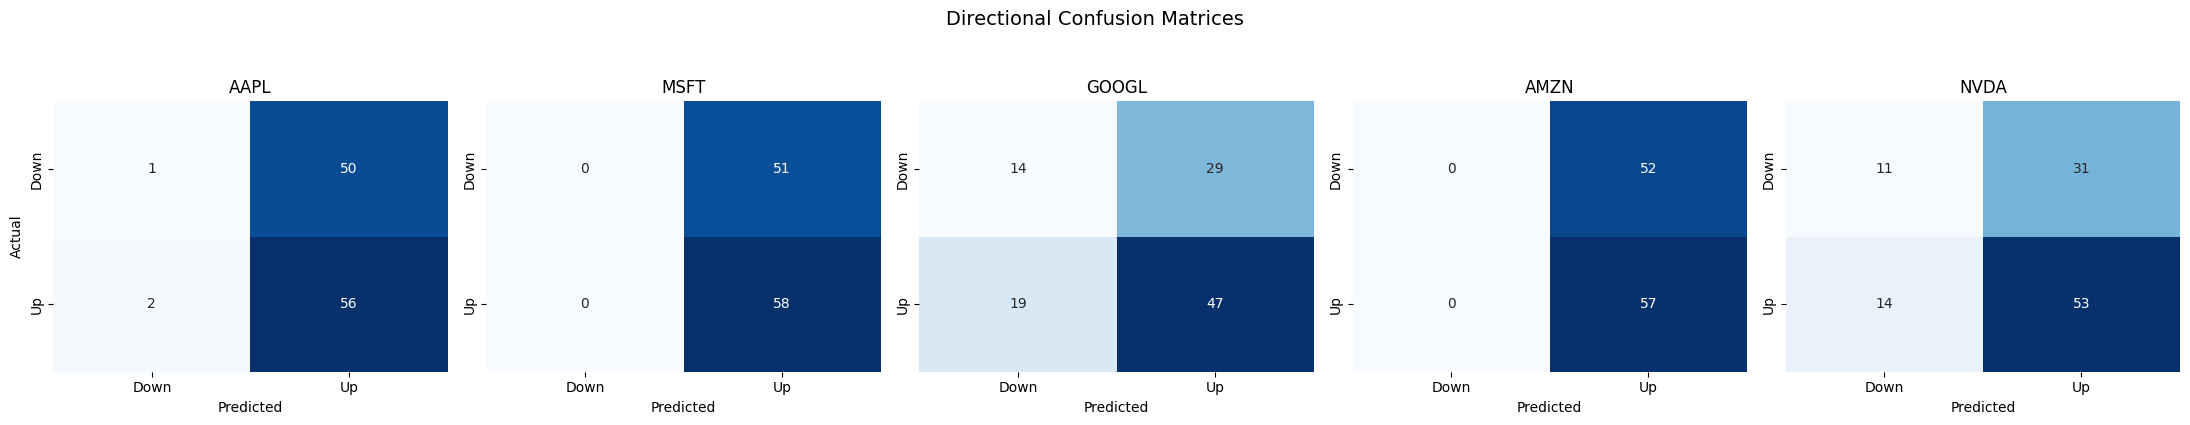

Saved: ../../data/results/lstm_confusion_matrices.png


In [15]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, ticker in zip(axes, TICKERS):
    td = pred_df[pred_df['Ticker'] == ticker]
    cm = confusion_matrix(td['Actual_Direction'], td['Pred_Direction'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], cbar=False)
    ax.set_title(f'{ticker}', fontsize=12)
    ax.set_xlabel('Predicted')
    if ax == axes[0]:
        ax.set_ylabel('Actual')

plt.suptitle('Directional Confusion Matrices', fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/lstm_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/lstm_confusion_matrices.png')

## 13. Weekly Stock Rankings

Each week, rank stocks by predicted probability of going up. Higher probability = rank 1 (most confident it will rise).

In [16]:
pivot_pred = pred_df.pivot_table(index='Date', columns='Ticker', values='Predicted_Return')
pivot_actual = pred_df.pivot_table(index='Date', columns='Ticker', values='Actual_Return')

predicted_ranks = pivot_pred.rank(axis=1, ascending=False).astype(int)
actual_ranks = pivot_actual.rank(axis=1, ascending=False).astype(int)

rank_matches = (predicted_ranks == actual_ranks).mean()
print('Per-stock ranking accuracy:')
for ticker in TICKERS:
    if ticker in rank_matches:
        bar = '#' * int(rank_matches[ticker] * 50)
        print(f'  {ticker}: {rank_matches[ticker]:.1%}  {bar}')

overall_rank_acc = (predicted_ranks == actual_ranks).values.mean()
print(f'\nOverall ranking accuracy: {overall_rank_acc:.1%}  (random: 20.0%)')

pred_top1 = pivot_pred.idxmax(axis=1)
actual_top1 = pivot_actual.idxmax(axis=1)
top1_acc = (pred_top1 == actual_top1).mean()
print(f'Top-1 accuracy (best stock): {top1_acc:.1%}  (random: 20.0%)')

top2_acc_list = []
for date in pivot_pred.index:
    pred_top2 = pivot_pred.loc[date].nlargest(2).index.tolist()
    actual_best = pivot_actual.loc[date].idxmax()
    top2_acc_list.append(actual_best in pred_top2)
top2_acc = np.mean(top2_acc_list)
print(f'Top-2 accuracy (best in top 2): {top2_acc:.1%}  (random: 40.0%)')

rankings_df = predicted_ranks.copy()
rankings_df.columns = [f'Rank_{t}' for t in rankings_df.columns]
rankings_df.to_csv(f'{OUT_DIR}/lstm_rankings.csv')
print(f'\nSaved: {OUT_DIR}/lstm_rankings.csv')

Per-stock ranking accuracy:
  AAPL: 24.8%  ############
  MSFT: 25.7%  ############
  GOOGL: 22.0%  ###########
  AMZN: 17.4%  ########
  NVDA: 30.3%  ###############

Overall ranking accuracy: 24.0%  (random: 20.0%)
Top-1 accuracy (best stock): 20.2%  (random: 20.0%)
Top-2 accuracy (best in top 2): 36.7%  (random: 40.0%)

Saved: ../../data/results/lstm_rankings.csv


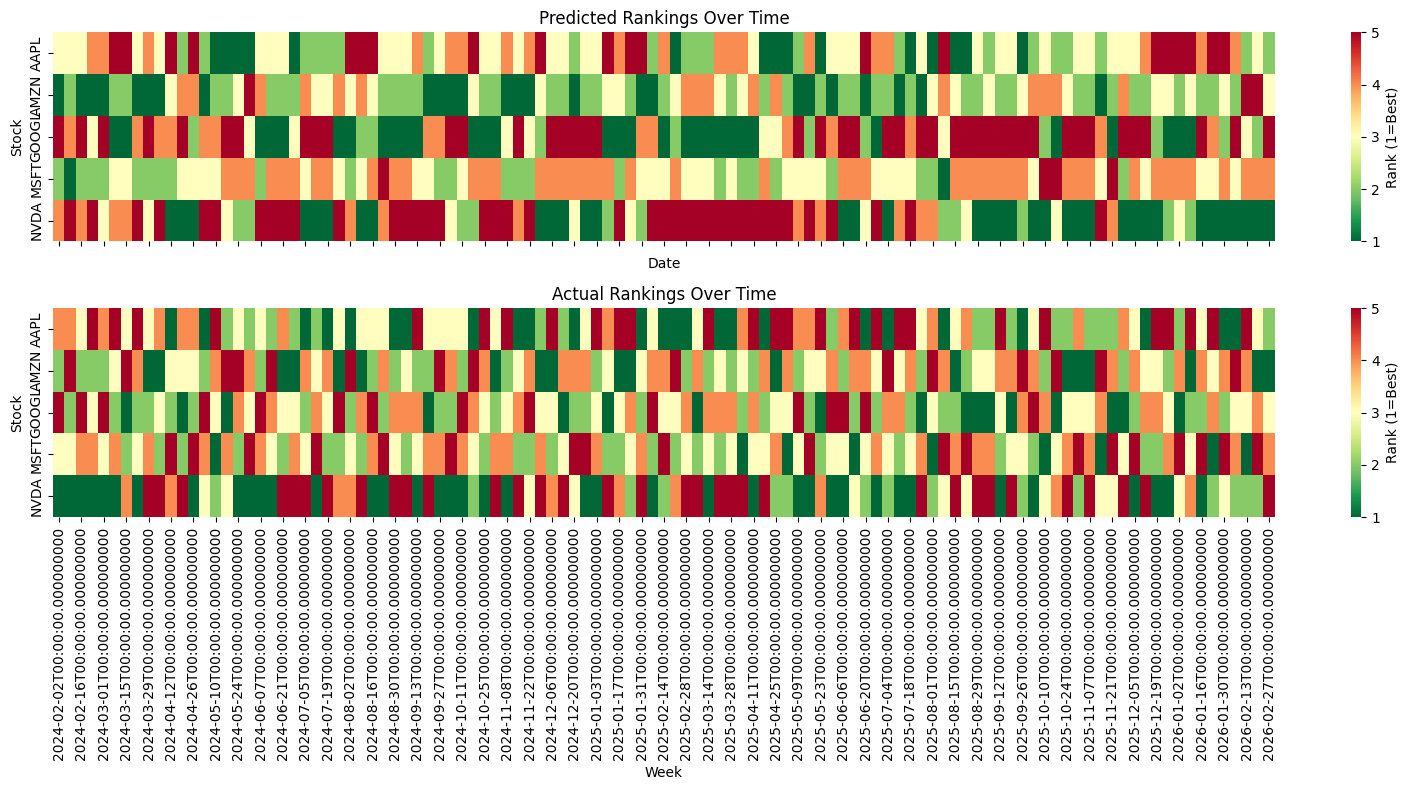

Saved: ../../data/results/lstm_ranking_heatmap.png


In [17]:
# Ranking heatmaps
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

sns.heatmap(predicted_ranks.T, cmap='RdYlGn_r', ax=axes[0],
            cbar_kws={'label': 'Rank (1=Best)'}, linewidths=0)
axes[0].set_title('Predicted Rankings Over Time', fontsize=12)
axes[0].set_ylabel('Stock')
axes[0].set_xticklabels([])

sns.heatmap(actual_ranks.T, cmap='RdYlGn_r', ax=axes[1],
            cbar_kws={'label': 'Rank (1=Best)'}, linewidths=0)
axes[1].set_title('Actual Rankings Over Time', fontsize=12)
axes[1].set_ylabel('Stock')
axes[1].set_xlabel('Week')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/lstm_ranking_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/lstm_ranking_heatmap.png')

## 14. Metrics Summary

In [18]:
metrics_df = pd.DataFrame(all_metrics).T
metrics_df.index.name = 'Ticker'

print('=' * 65)
print('  LSTM MODEL — FINAL METRICS')
print('=' * 65)
print(metrics_df.to_string())
print(f'\nOverall ranking accuracy: {overall_rank_acc:.1%}  (random: 20%)')
print(f'Top-1 accuracy:           {top1_acc:.1%}  (random: 20%)')
print(f'Top-2 accuracy:           {top2_acc:.1%}  (random: 40%)')

metrics_df

  LSTM MODEL — FINAL METRICS
        Directional Accuracy  Prob Std  Preds Up  Preds Down  Stopped Epoch  Test Samples
Ticker                                                                                   
AAPL                  0.5229    0.0386     106.0         3.0           21.0         109.0
MSFT                  0.5321    0.0119     109.0         0.0           21.0         109.0
GOOGL                 0.5596    0.0790      76.0        33.0           31.0         109.0
AMZN                  0.5229    0.0235     109.0         0.0           21.0         109.0
NVDA                  0.5872    0.1094      84.0        25.0           28.0         109.0

Overall ranking accuracy: 24.0%  (random: 20%)
Top-1 accuracy:           20.2%  (random: 20%)
Top-2 accuracy:           36.7%  (random: 40%)


,Directional Accuracy,Prob Std,Preds Up,Preds Down,Stopped Epoch,Test Samples
Ticker,,,,,,
AAPL,0.5229,0.0386,106.0,3.0,21.0,109.0
MSFT,0.5321,0.0119,109.0,0.0,21.0,109.0
GOOGL,0.5596,0.0790,76.0,33.0,31.0,109.0
AMZN,0.5229,0.0235,109.0,0.0,21.0,109.0
NVDA,0.5872,0.1094,84.0,25.0,28.0,109.0


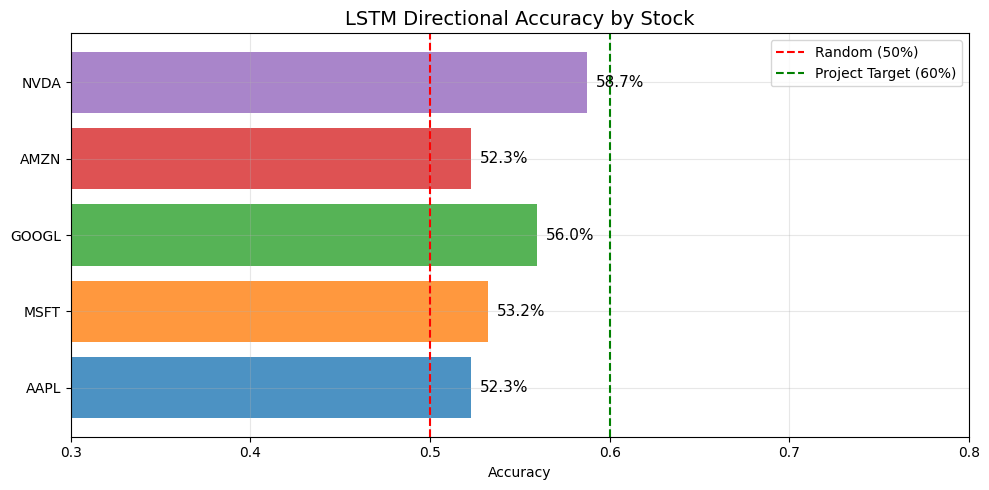

Saved: ../../data/results/lstm_accuracy_bar.png


In [19]:
# Accuracy bar chart
fig, ax = plt.subplots(figsize=(10, 5))
accs = [all_metrics[t]['Directional Accuracy'] for t in TICKERS]
bars = ax.barh(TICKERS, accs, color=[COLORS[t] for t in TICKERS], alpha=0.8)
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, label='Random (50%)')
ax.axvline(x=0.6, color='green', linestyle='--', linewidth=1.5, label='Project Target (60%)')
for i, v in enumerate(accs):
    ax.text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=11)
ax.set_title('LSTM Directional Accuracy by Stock', fontsize=14)
ax.set_xlabel('Accuracy')
ax.set_xlim(0.3, 0.8)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/lstm_accuracy_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/lstm_accuracy_bar.png')

## 15. Save Summary

In [20]:
with open(f'{OUT_DIR}/lstm_summary.txt', 'w') as f:
    f.write('LSTM Model Summary\n')
    f.write('=' * 50 + '\n\n')
    f.write('Approach: Binary Classification (Up vs Down)\n')
    f.write('Architecture: LSTM(8) > Dense(1, sigmoid)\n')
    f.write(f'Input: {SEQUENCE_LENGTH} weeks of raw weekly returns\n')
    f.write(f'Optimizer: Adam (lr=0.01) | Loss: Binary Crossentropy\n')
    f.write(f'Batch Size: {BATCH_SIZE} | Max Epochs: {EPOCHS} | Patience: {PATIENCE}\n\n')
    f.write('Per-Stock Metrics:\n')
    f.write(metrics_df.to_string())
    f.write(f'\n\nOverall Ranking Accuracy: {overall_rank_acc:.1%} (random: 20%)\n')
    f.write(f'Top-1 Accuracy: {top1_acc:.1%} (random: 20%)\n')
    f.write(f'Top-2 Accuracy: {top2_acc:.1%} (random: 40%)\n')

print(f'Saved: {OUT_DIR}/lstm_summary.txt')
print('\nLSTM modeling complete!')
print('Next step: run backtest.py to see portfolio P&L')

Saved: ../../data/results/lstm_summary.txt

LSTM modeling complete!
Next step: run backtest.py to see portfolio P&L


## 16. Interpretation

### Why Classification Instead of Regression?
In our initial experiments, regression-based LSTM (predicting exact return values) collapsed to flat near-zero predictions for all stocks. This is a well-documented issue in financial ML — the model learns that predicting zero minimizes MSE because returns are noisy and centered near zero. Switching to binary classification forces the model to commit to a direction (up/down) and produces meaningful probability scores that vary across stocks and time.

### Model Design Rationale
We deliberately used a minimal architecture (8 LSTM units, no dropout, single feature) because:
- Only ~350 training samples per stock — a larger model would memorize noise
- Weekly returns have extremely low signal-to-noise ratio
- Raw unscaled returns preserve natural value ranges better than StandardScaler

### Why Stock Prediction Is Hard
- Professional quant funds with billions in resources typically achieve 52-55% directional accuracy
- Market efficiency means most predictable patterns are already priced in
- External events (earnings, geopolitics, sentiment) dominate short-term returns

### Ranking for Portfolio Allocation
The probability scores serve as confidence levels for ranking: a stock with P(Up)=0.7 is ranked higher than one with P(Up)=0.4. Even marginal ranking improvements over random allocation can generate excess returns in the portfolio backtest.

### Limitations
- Single input feature (past 4 weeks of returns) — no fundamental or sentiment data
- ~350 training samples per stock is small for deep learning
- Each stock modeled independently — no cross-stock learning
- Market regime changes reduce generalization across time periods